In [1]:
library(CellChat)
library(patchwork)
library(Seurat)
library(ggplot2)
library(RColorBrewer)

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: ggplot2

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:BiocGenerics’:

    intersect


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘Seurat’


The following object is masked from ‘package:igraph’:

    components




In [2]:
get_theme <- function(size=12, angle=45) {
    defined_theme = theme_bw(base_size=size) + theme(legend.title=element_text(size=size), strip.text=element_text(size=size), legend.text=element_text(size=size), axis.title.x=element_text(size=size), axis.title.y=element_text(size=size), axis.text.y=element_text(size=size), axis.text.x=element_text(size=size, angle=angle, hjust = 1, vjust=1.05), legend.position="bottom", legend.box = "horizontal") 
    defined_theme
}

fig.size <- function(h, w) {
    options(repr.plot.height = h, repr.plot.width = w)
}

In [3]:
data <- readRDS("../phaseZ_finalize_figs/250711_niches.rds")

In [4]:
head(data@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,id,X,Y,npts,area,perimeter,sample_id,⋯,RNA_snn_res.1.2,RNA_snn_res.1.4,RNA_snn_res.1.6,niche_label,snn_0.2,snn_0.4,snn_0.6,snn_0.8,snn_1,niche_label_fine
,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,⋯,<fct>,<fct>,<fct>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
BS21-N65682A2__20241025_1,BS21-N65682A2,2830,1342,BS21-N65682A2__20241025_1,529.0507,625.4208,15,2816.419,271.2288,BS21-N65682A2__20241025,⋯,0,18,4,Proximal Tubule,1,2,2,2,0,Proximal Tubule
BS21-N65682A2__20241025_2,BS21-N65682A2,1823,1015,BS21-N65682A2__20241025_2,729.7490,784.1590,15,2056.328,235.6431,BS21-N65682A2__20241025,⋯,0,1,2,Proximal Tubule,1,2,2,3,0,Proximal Tubule
BS21-N65682A2__20241025_3,BS21-N65682A2,2806,1493,BS21-N65682A2__20241025_3,884.8588,645.9624,16,1867.530,184.4595,BS21-N65682A2__20241025,⋯,8,10,8,Proximal Tubule,0,1,6,3,3,Proximal Tubule
BS21-N65682A2__20241025_4,BS21-N65682A2,4441,1707,BS21-N65682A2__20241025_4,694.9296,873.8228,28,1597.262,205.7916,BS21-N65682A2__20241025,⋯,3,15,12,Immune,0,0,1,1,5,TLS-Like
BS21-N65682A2__20241025_5,BS21-N65682A2,1655,1039,BS21-N65682A2__20241025_5,744.6097,840.5749,9,1331.611,194.9633,BS21-N65682A2__20241025,⋯,11,6,5,Fibrosis & Interstitium,0,0,0,0,1,Fibrosis with Inflammation
BS21-N65682A2__20241025_6,BS21-N65682A2,2855,1358,BS21-N65682A2__20241025_6,463.5995,580.6815,9,1007.401,147.6383,BS21-N65682A2__20241025,⋯,19,21,22,Vessel,5,7,8,10,11,Vessel


In [5]:
table(data$sample_id)


  BS2_61615A1__20240803 BS21-N65682A2__20241025  BS22_12012A1__20240803 
                   2387                    2447                    3430 
BS22-T41795A1__20241025  BS23_49001A1__20240803  BS23_52206A2__20240803 
                   1444                    4521                    3986 
BS24-M35359A1__20241025 BS24-R31519A2__20241025 
                   1977                    2498 

In [6]:
sample_label_map <- c(
  "BS21-N65682A2__20241025" = "cellchat_case1",
  "BS22-T41795A1__20241025" = "cellchat_case2",
  "BS23_49001A1__20240803"  = "cellchat_case3",
  "BS23_52206A2__20240803"  = "cellchat_case4",
  
  "BS2_61615A1__20240803"   = "cellchat_control1",
  "BS22_12012A1__20240803"  = "cellchat_control2",
  "BS24-M35359A1__20241025" = "cellchat_control3",
  "BS24-R31519A2__20241025" = "cellchat_control4"
)

In [7]:
table(data@meta.data$sample_id)


  BS2_61615A1__20240803 BS21-N65682A2__20241025  BS22_12012A1__20240803 
                   2387                    2447                    3430 
BS22-T41795A1__20241025  BS23_49001A1__20240803  BS23_52206A2__20240803 
                   1444                    4521                    3986 
BS24-M35359A1__20241025 BS24-R31519A2__20241025 
                   1977                    2498 

In [8]:
cellchat.case = list()

In [9]:
for (i in seq_along(1:4)) {
data.input1 = Seurat::GetAssayData(subset(data, sample_id%in%names(sample_label_map[grep("case", sample_label_map)])[i]), slot = "data", assay = "RNA")
    
meta1 <- subset(data, sample_id%in%names(sample_label_map[grep("case", sample_label_map)])[i])@meta.data
meta1$labels <- meta1$niche_label_fine
meta1$samples <- meta1$sample_id

spatial.locs = meta1[,c('X', 'Y')]
spatial.factors = data.frame(samples = meta1[,'samples'])
spatial.factors$ratio = 1 # The Xenium cell feature matrix and transcripts result coordinates are in microns.
spatial.factors$tol = 5 # Tolerance = half the size of a typical human cell 

#Create a CellChat object
cellchat1 <- createCellChat(
  object = data.input1,      # your normalized expression matrix
  meta = meta1,
  group.by = "niche_label_fine",      # what to cluster/group by
  datatype = "spatial",     
  coordinates = as.matrix(spatial.locs),     # your custom X/Y
  spatial.factors = spatial.factors
)

CellChatDB <- CellChatDB.human # use CellChatDB.human if running on human data
# use a subset of CellChatDB for cell-cell communication analysis
CellChatDB.use <- subsetDB(CellChatDB, search = "Secreted Signaling", key = "annotation") # use Secreted Signaling
# set the used database in the object
cellchat1@DB <- CellChatDB.use

ptm = Sys.time()
# subset the expression data of signaling genes for saving computation cost
cellchat1 <- subsetData(cellchat1) # This step is necessary even if using the whole database
future::plan("multisession", workers = 1) 
cellchat1 <- identifyOverExpressedGenes(cellchat1)
cellchat1 <- identifyOverExpressedInteractions(cellchat1)
#> The number of highly variable ligand-receptor pairs used for signaling inference is 422 

execution.time = Sys.time() - ptm
print(as.numeric(execution.time, units = "secs"))


cellchat1 <- computeCommunProb(cellchat1,
                              type = "truncatedMean",
                              trim = 0.1,
                              distance.use = F,
                              interaction.range = 200,  # reduced from 250
                              scale.distance = NULL,
                              contact.dependent = T,
                              contact.range = 30)       # reduced from 100


execution.time = Sys.time() - ptm
print(as.numeric(execution.time, units = "secs"))

cellchat1 <- filterCommunication(cellchat1, min.cells = 10)

cellchat1 <- computeCommunProbPathway(cellchat1)

cellchat1 <- aggregateNet(cellchat1)

execution.time = Sys.time() - ptm
print(as.numeric(execution.time, units = "secs"))
#> [1] 188.3582
    
    cellchat.case[[names(sample_label_map[grep("case", sample_label_map)])[i]]] = cellchat1
}

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


[1] "Create a CellChat object from a data matrix"
Create a CellChat object from spatial transcriptomics data... 
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Basophils, CD8 Infiltrated Kidney, Collecting Duct, Distal Convoluted Tubule, Fibrosis with Inflammation, Glomerulus, Inflammation with Fibrosis, Injured Proximal Tubule, Low QC Fibrosis, Myeloid Inflammation, Plasma Cells, Plasmacytoid Dendritic Cells, Proliferating CD8 T Cells, Proximal Tubule, Thick Ascending Limb, Tissue-Resident Myeloid, TLS-Like, Tubule Fibrosis, Vascular Fibrosis, Vessel 
The number of highly variable ligand-receptor pairs used for signaling inference is 382 
[1] 0.324254
truncatedMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on spatial transcriptomics data without distance values as constraints of the computed communication probability <<< [2025-09-29 21:15:03.814984]"
Molecules of the input L-R pairs are 

In [12]:
cellchat.cont = list()

In [13]:
for (i in seq_along(1:4)) {
data.input2 = Seurat::GetAssayData(subset(data, sample_id%in%names(sample_label_map[grep("control", sample_label_map)])[i]), slot = "data", assay = "RNA")

meta2 <- subset(data, sample_id%in%names(sample_label_map[grep("control", sample_label_map)])[i])@meta.data
meta2$labels <- meta2$niche_label_fine
meta2$samples <- meta2$sample_id

spatial.locs = meta2[,c('X', 'Y')]
spatial.factors = data.frame(samples = meta2[,'samples'])
spatial.factors$ratio = 1 # The Xenium cell feature matrix and transcripts result coordinates are in microns.
spatial.factors$tol = 5 # Tolerance = half the size of a typical human cell 

#Create a CellChat object
cellchat2 <- createCellChat(
  object = data.input2,      # your normalized expression matrix
  meta = meta2,
  group.by = "niche_label_fine",      # what to cluster/group by
  datatype = "spatial",     
  coordinates = as.matrix(spatial.locs),     # your custom X/Y
  spatial.factors = spatial.factors
)

CellChatDB <- CellChatDB.human # use CellChatDB.human if running on human data
# use a subset of CellChatDB for cell-cell communication analysis
CellChatDB.use <- subsetDB(CellChatDB, search = "Secreted Signaling", key = "annotation") # use Secreted Signaling
# set the used database in the object
cellchat2@DB <- CellChatDB.use

ptm = Sys.time()
# subset the expression data of signaling genes for saving computation cost
cellchat2 <- subsetData(cellchat2) # This step is necessary even if using the whole database
future::plan("multisession", workers = 1) 
cellchat2 <- identifyOverExpressedGenes(cellchat2)
cellchat2 <- identifyOverExpressedInteractions(cellchat2)
#> The number of highly variable ligand-receptor pairs used for signaling inference is 422 

execution.time = Sys.time() - ptm
print(as.numeric(execution.time, units = "secs"))

# ptm = Sys.time()
# cellchat <- computeCommunProb(cellchat, type = "truncatedMean", trim = 0.1, 
#                               distance.use = FALSE, interaction.range = 250, scale.distance = NULL,
#                               contact.dependent = TRUE, contact.range = 100)

cellchat2 <- computeCommunProb(cellchat2,
                              type = "truncatedMean",
                              trim = 0.1,
                              distance.use = F,
                              interaction.range = 200,  # reduced from 250
                              scale.distance = NULL,
                              contact.dependent = T,
                              contact.range = 30)       # reduced from 100

execution.time = Sys.time() - ptm
print(as.numeric(execution.time, units = "secs"))

cellchat2 <- filterCommunication(cellchat2, min.cells = 10)
cellchat2 <- computeCommunProbPathway(cellchat2)
cellchat2 <- aggregateNet(cellchat2)

execution.time = Sys.time() - ptm
print(as.numeric(execution.time, units = "secs"))
    
        cellchat.cont[[names(sample_label_map[grep("control", sample_label_map)])[i]]] = cellchat2

#> [1] 188.3582
}

[1] "Create a CellChat object from a data matrix"
Create a CellChat object from spatial transcriptomics data... 
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Basophils, CD8 Infiltrated Kidney, Collecting Duct, Distal Convoluted Tubule, Fibrosis with Inflammation, Glomerulus, Inflammation with Fibrosis, Injured Proximal Tubule, Low QC Fibrosis, Myeloid Inflammation, Plasma Cells, Proliferating CD8 T Cells, Proximal Tubule, Thick Ascending Limb, Tissue-Resident Myeloid, TLS-Like, Tubule Fibrosis, Vascular Fibrosis, Vessel 
The number of highly variable ligand-receptor pairs used for signaling inference is 361 
[1] 0.4121408
truncatedMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on spatial transcriptomics data without distance values as constraints of the computed communication probability <<< [2025-09-29 21:27:09.325102]"
Molecules of the input L-R pairs are diffusible. Run CellChat in a

In [14]:
saveRDS(cellchat.cont, "cellchat.cont.rds")

In [15]:
saveRDS(cellchat.case, "cellchat.case.rds")

In [277]:
cellchat.cont <- readRDS("cellchat.cont.rds")

In [278]:
cellchat.case <- readRDS("cellchat.case.rds")

In [279]:
names(cellchat.cont)

[1] "BS2_61615A1__20240803"   "BS22_12012A1__20240803" 
[3] "BS24-M35359A1__20241025" "BS24-R31519A2__20241025"

In [280]:
names(cellchat.case)

[1] "BS21-N65682A2__20241025" "BS22-T41795A1__20241025"
[3] "BS23_49001A1__20240803"  "BS23_52206A2__20240803"

In [281]:
setdiff(names(table(cellchat1@meta$niche_label_fine)), names(table(cellchat2@meta$niche_label_fine)))

[1] "Myeloid Inflammation"         "Plasma Cells"                
[3] "Plasmacytoid Dendritic Cells" "Skeletal Muscle"

In [282]:
group.new = unique(intersect(levels(cellchat1@idents), levels(cellchat2@idents)))

In [283]:
table(cellchat.case[[1]]@idents)


                   Basophils       CD8 Infiltrated Kidney 
                          65                          130 
                         150                           54 
  Fibrosis with Inflammation                   Glomerulus 
                         247                          130 
  Inflammation with Fibrosis      Injured Proximal Tubule 
                          60                          236 
             Low QC Fibrosis         Myeloid Inflammation 
                          76                           69 
                Plasma Cells Plasmacytoid Dendritic Cells 
                          37                           42 
   Proliferating CD8 T Cells              Proximal Tubule 
                          29                          456 
        Thick Ascending Limb      Tissue-Resident Myeloid 
                         130                          116 
                    TLS-Like              Tubule Fibrosis 
                         122                          1

In [284]:
# Find intersection of all sample labels across CellChat objects
common_labels1 <- Reduce(function(x, y) {
  intersect(x, y)
}, lapply(cellchat.case, function(obj) unique(obj@idents)))

In [285]:
# Find intersection of all sample labels across CellChat objects
common_labels2 <- Reduce(function(x, y) {
  intersect(x, y)
}, lapply(cellchat.cont, function(obj) unique(obj@idents)))

In [286]:
# common_labels = intersect(common_labels1, common_labels2)

In [287]:
# cellchat.case = lapply(cellchat.case, function(obj) {
#     obj@data.smooth = matrix(nrow = 0,ncol = 0)
#     obj = subsetCellChat(obj,idents.use = common_labels)
#     obj
#     })

In [288]:
# cellchat.cont = lapply(cellchat.cont, function(obj) {
#     obj@data.smooth = matrix(nrow = 0,ncol = 0)
#     obj = subsetCellChat(obj,idents.use = common_labels)
#     obj
#     })

In [289]:
common_pathways <- intersect(cellchat.case[[1]]@netP$pathways, cellchat.cont[[1]]@netP$pathways)

In [290]:
common_pathways

[1] "CXCL"       "GALECTIN"   "IL16"       "PDGF"       "GAS"       
 [6] "TGFb"       "PARs"       "PERIOSTIN"  "FGF"        "GRN"       
[11] "COMPLEMENT" "PROS"       "BMP"        "VEGF"       "CCL"       
[16] "EGF"        "CSF"        "GDF"        "ncWNT"      "TRAIL"     
[21] "HGF"        "IGF"        "ANGPTL"     "TNF"        "KIT"       
[26] "KLK"        "CALCR"      "PLAU"       "LIFR"       "ANGPT"     
[31] "ACTIVIN"    "EDN"        "NPR1"       "TWEAK"      "IL1"       
[36] "WNT"        "CX3C"       "PROCR"      "NT"         "HH"        
[41] "PROC"       "APELIN"

In [291]:
# cellchat1 <- subsetCommunication(cellchat1, signaling = common_pathways)
# cellchat2 <- subsetCommunication(cellchat2, signaling = common_pathways)

In [292]:
#object.list = list(cellchat1,cellchat2)
#object.list <- list(AIN = cellchat1, ATN = cellchat2)
object.list <- cellchat.case
cellchat.case.obj <- mergeCellChat(object.list, add.names = names(object.list), cell.prefix = TRUE)

Warning message in mergeCellChat(object.list, add.names = names(object.list), cell.prefix = TRUE):
“Prefix cell names!”


The cell barcodes in merged 'meta' is  BS21-N65682A2__20241025_1 BS21-N65682A2__20241025_2 BS21-N65682A2__20241025_3 BS21-N65682A2__20241025_4 BS21-N65682A2__20241025_5 BS21-N65682A2__20241025_6 


Warning message in mergeCellChat(object.list, add.names = names(object.list), cell.prefix = TRUE):
“The cell barcodes in merged 'meta' is different from those in the used data matrix.
              We now simply assign the colnames in the data matrix to the rownames of merged 'mata'!”
Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



In [293]:
#object.list = list(cellchat1,cellchat2)
#object.list <- list(AIN = cellchat1, ATN = cellchat2)
object.list2 <- cellchat.cont
cellchat.cont.obj <- mergeCellChat(object.list2, add.names = names(object.list2), cell.prefix = TRUE)

Warning message in mergeCellChat(object.list2, add.names = names(object.list2), :
“Prefix cell names!”


The cell barcodes in merged 'meta' is  BS2_61615A1__20240803_1 BS2_61615A1__20240803_2 BS2_61615A1__20240803_3 BS2_61615A1__20240803_4 BS2_61615A1__20240803_5 BS2_61615A1__20240803_6 


Warning message in mergeCellChat(object.list2, add.names = names(object.list2), :
“The cell barcodes in merged 'meta' is different from those in the used data matrix.
              We now simply assign the colnames in the data matrix to the rownames of merged 'mata'!”
Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



In [294]:
table(cellchat2@meta$samples)


BS21-N65682A2__20241025 BS22-T41795A1__20241025  BS23_49001A1__20240803 
                   2299                    1366                    3919 
 BS23_52206A2__20240803 
                   3440 

In [295]:
table(cellchat@meta$samples)


BS21-N65682A2__20241025 BS22-T41795A1__20241025  BS23_49001A1__20240803 
                   2299                    1366                    3919 
 BS23_52206A2__20240803 
                   3440 

In [296]:
sample_translator <- c("BS21-N65682A2__20241025" = "1",
                       "BS22_12012A1__20240803" = "2",
                       "BS22-T41795A1__20241025" = "3",
                       "BS2_61615A1__20240803" = "4",
                       "BS23_49001A1__20240803" = "5",
                       "BS23_52206A2__20240803" = "6",
                       "BS24-R31519A2__20241025" = "7",
                       "BS24-M35359A1__20241025" = "8")

In [297]:
names(cellchat.case.obj@net)

[1] "BS21-N65682A2__20241025" "BS22-T41795A1__20241025"
[3] "BS23_49001A1__20240803"  "BS23_52206A2__20240803"

In [298]:
names(cellchat.case.obj@net)

[1] "BS21-N65682A2__20241025" "BS22-T41795A1__20241025"
[3] "BS23_49001A1__20240803"  "BS23_52206A2__20240803"

In [299]:
names(cellchat.cont.obj@net)

[1] "BS2_61615A1__20240803"   "BS22_12012A1__20240803" 
[3] "BS24-M35359A1__20241025" "BS24-R31519A2__20241025"

In [300]:
names(cellchat.case.obj@net) = sample_translator[match(names(cellchat.case.obj@net), names(sample_translator))]

In [301]:
names(cellchat.cont.obj@net) = sample_translator[match(names(cellchat.cont.obj@net), names(sample_translator))]

In [302]:
fig.size(6, 9)
ptm = Sys.time()
gg1 <- compareInteractions(cellchat.case.obj, show.legend = F) +ylim(0, 13000)+theme_bw(base_size=16) + get_theme(angle=0, size=18) + ggtitle("AIN") + theme(legend.position='none')
gg2 <- compareInteractions(cellchat.cont.obj, show.legend = F) +ylim(0, 13000)+theme_bw(base_size=16)+ get_theme(angle=0, size=18) + ggtitle("ATN")+ theme(legend.position='none')
figs6a = gg1 + gg2

ggsave("SuppFig60_CXCL_comparison.pdf", width=6, height=5)

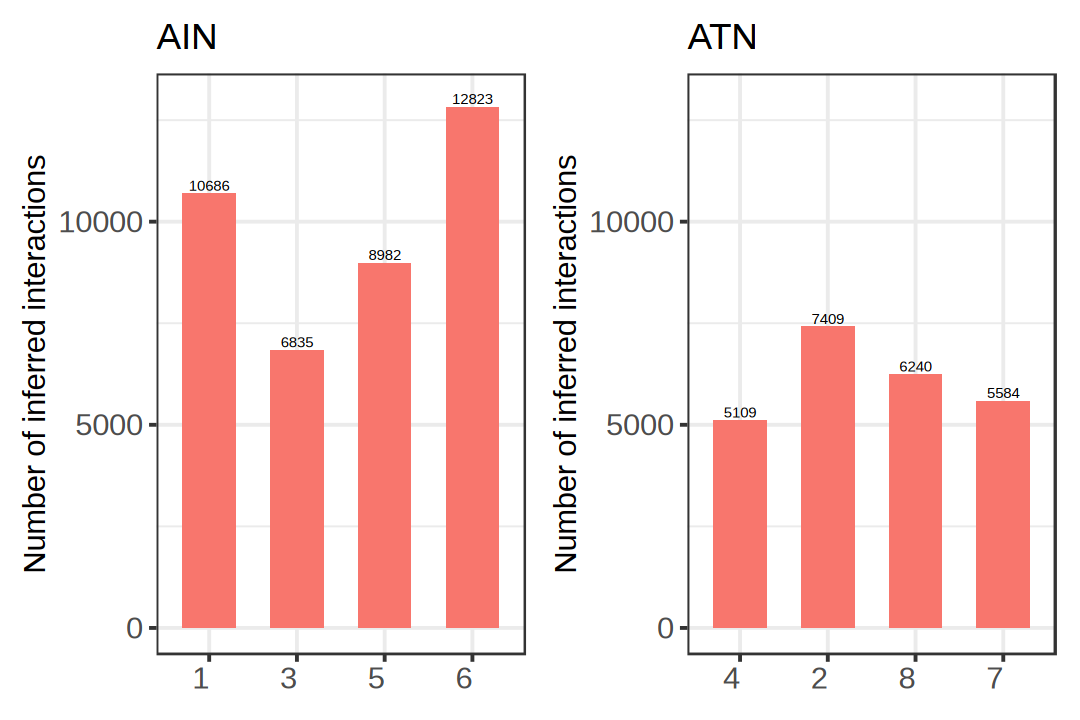

In [303]:
figs6a

In [304]:
# fig.size(12, 24)
# num.link <- sapply(cellchat.case, function(x) {rowSums(x@net$count) + colSums(x@net$count)-diag(x@net$count)})

# weight.MinMax <- c(min(num.link), max(num.link)) # control the dot size in the different datasets
# gg <- list()
# for (i in 1:length(object.list)) {
#   gg[[i]] <- netAnalysis_signalingRole_scatter(object.list[[i]], title = names(object.list)[i], weight.MinMax = weight.MinMax)
# }
# patchwork::wrap_plots(plots = gg)

In [305]:
# fig.size(12, 24)
# num.link <- sapply(cellchat.cont, function(x) {rowSums(x@net$count) + colSums(x@net$count)-diag(x@net$count)})

# weight.MinMax <- c(min(num.link), max(num.link)) # control the dot size in the different datasets
# gg <- list()
# for (i in 1:length(object.list)) {
#   gg[[i]] <- netAnalysis_signalingRole_scatter(object.list[[i]], title = names(object.list)[i], weight.MinMax = weight.MinMax)
# }
# #> Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways
# #> Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways
# patchwork::wrap_plots(plots = gg)

In [306]:
table(cellchat@meta$labels)


                 Basophils     CD8 Infiltrated Kidney 
                       190                       1050 
                       631                        103 
Fibrosis with Inflammation                 Glomerulus 
                      1193                        344 
Inflammation with Fibrosis    Injured Proximal Tubule 
                       328                       1199 
           Low QC Fibrosis  Proliferating CD8 T Cells 
                       317                        252 
           Proximal Tubule       Thick Ascending Limb 
                      1206                       1501 
   Tissue-Resident Myeloid                   TLS-Like 
                       581                        529 
           Tubule Fibrosis          Vascular Fibrosis 
                       720                        550 
                    Vessel 
                       330 

In [307]:
pathways.show <- c("CXCL", 'CCL') 
#pathways.show = common_pathways

In [308]:
pathways.show

[1] "CXCL" "CCL"

In [309]:
fig.size(15, 32)

p1 = netAnalysis_contribution(cellchat.case[[1]], signaling = pathways.show, thresh=0.01, font.size=16) + xlab("AIN")
p2 = netAnalysis_contribution(cellchat.case[[2]], signaling = pathways.show, thresh=0.01, font.size=16)
p3 = netAnalysis_contribution(cellchat.case[[3]], signaling = pathways.show, thresh=0.01, font.size=16)
p4 = netAnalysis_contribution(cellchat.case[[4]], signaling = pathways.show, thresh=0.01, font.size=16)

pcase = p1|p2|p3|p4

In [310]:
fig.size(15, 32)

p1 = netAnalysis_contribution(cellchat.cont[[1]], signaling = pathways.show, thresh=0.01, font.size=16) + xlab("ATN")
p2 = netAnalysis_contribution(cellchat.cont[[2]], signaling = pathways.show, thresh=0.01, font.size=16)
p3 = netAnalysis_contribution(cellchat.cont[[3]], signaling = pathways.show, thresh=0.01, font.size=16)
p4 = netAnalysis_contribution(cellchat.cont[[4]], signaling = pathways.show, thresh=0.01, font.size=16)

pcont = p1|p2|p3|p4

In [311]:
fig.size(15, 32)

figs6b = pcase / pcont

ggsave("SuppFig6a_CXCL_comparison.pdf", width=15, height=18)

In [312]:
length(table(cellchat1@meta$labels))

[1] 21

In [313]:
fig.size(9, 32)

p1 = netVisual_bubble(cellchat.case[[1]], sources.use = c('Plasma Cells', 'Myeloid Inflammation', 'CD8 Infiltrated Kidney'), targets.use = c(1:19), signaling = c("CCL","CXCL"), remove.isolate = FALSE, 
                  font.size=15)
p2 = netVisual_bubble(cellchat.case[[2]], sources.use = c('Plasma Cells', 'Myeloid Inflammation', 'CD8 Infiltrated Kidney'), targets.use = c(1:19), signaling = c("CCL","CXCL"), remove.isolate = FALSE, 
                  font.size=15)
p3 = netVisual_bubble(cellchat.case[[3]], sources.use = c('Plasma Cells', 'Myeloid Inflammation', 'CD8 Infiltrated Kidney'), targets.use = c(1:19), signaling = c("CCL","CXCL"), remove.isolate = FALSE, 
                  font.size=15)
p4 = netVisual_bubble(cellchat.case[[4]], sources.use = c('Plasma Cells', 'Myeloid Inflammation', 'CD8 Infiltrated Kidney'), targets.use = c(1:19), signaling = c("CCL","CXCL"), remove.isolate = FALSE, 
                  font.size=15) 

pcase = p1 | p2 | p3 | p4


fig.size(9, 32)

p1 = netVisual_bubble(cellchat.cont[[1]], sources.use = c('Plasma Cells', 'Myeloid Inflammation', 'CD8 Infiltrated Kidney'), targets.use = c(1:19), signaling = c("CCL","CXCL"), remove.isolate = FALSE, 
                  font.size=15)
p2 = netVisual_bubble(cellchat.cont[[2]], sources.use = c('Plasma Cells', 'Myeloid Inflammation', 'CD8 Infiltrated Kidney'), targets.use = c(1:19), signaling = c("CCL","CXCL"), remove.isolate = FALSE, 
                  font.size=15)
p3 = netVisual_bubble(cellchat.cont[[3]], sources.use = c('Plasma Cells', 'Myeloid Inflammation', 'CD8 Infiltrated Kidney'), targets.use = c(1:19), signaling = c("CCL","CXCL"), remove.isolate = FALSE, 
                  font.size=15)
p4 = netVisual_bubble(cellchat.cont[[4]], sources.use = c('Plasma Cells', 'Myeloid Inflammation', 'CD8 Infiltrated Kidney'), targets.use = c(1:19), signaling = c("CCL","CXCL"), remove.isolate = FALSE, 
                  font.size=15) 

pcont = p1 | p2 | p3 | p4

Comparing communications on a single object 


Comparing communications on a single object 


Comparing communications on a single object 


Comparing communications on a single object 


Comparing communications on a single object 


Comparing communications on a single object 


Comparing communications on a single object 


Comparing communications on a single object 




In [314]:
fig.size(16, 42)
figs6c = pcase / pcont
ggsave("SuppFig6_CXCL_comparison.pdf", width=45, height=16)

In [315]:
getwd()

[1] "/data/wei/qq06/xenium/phaseZ2_refactor_figs"

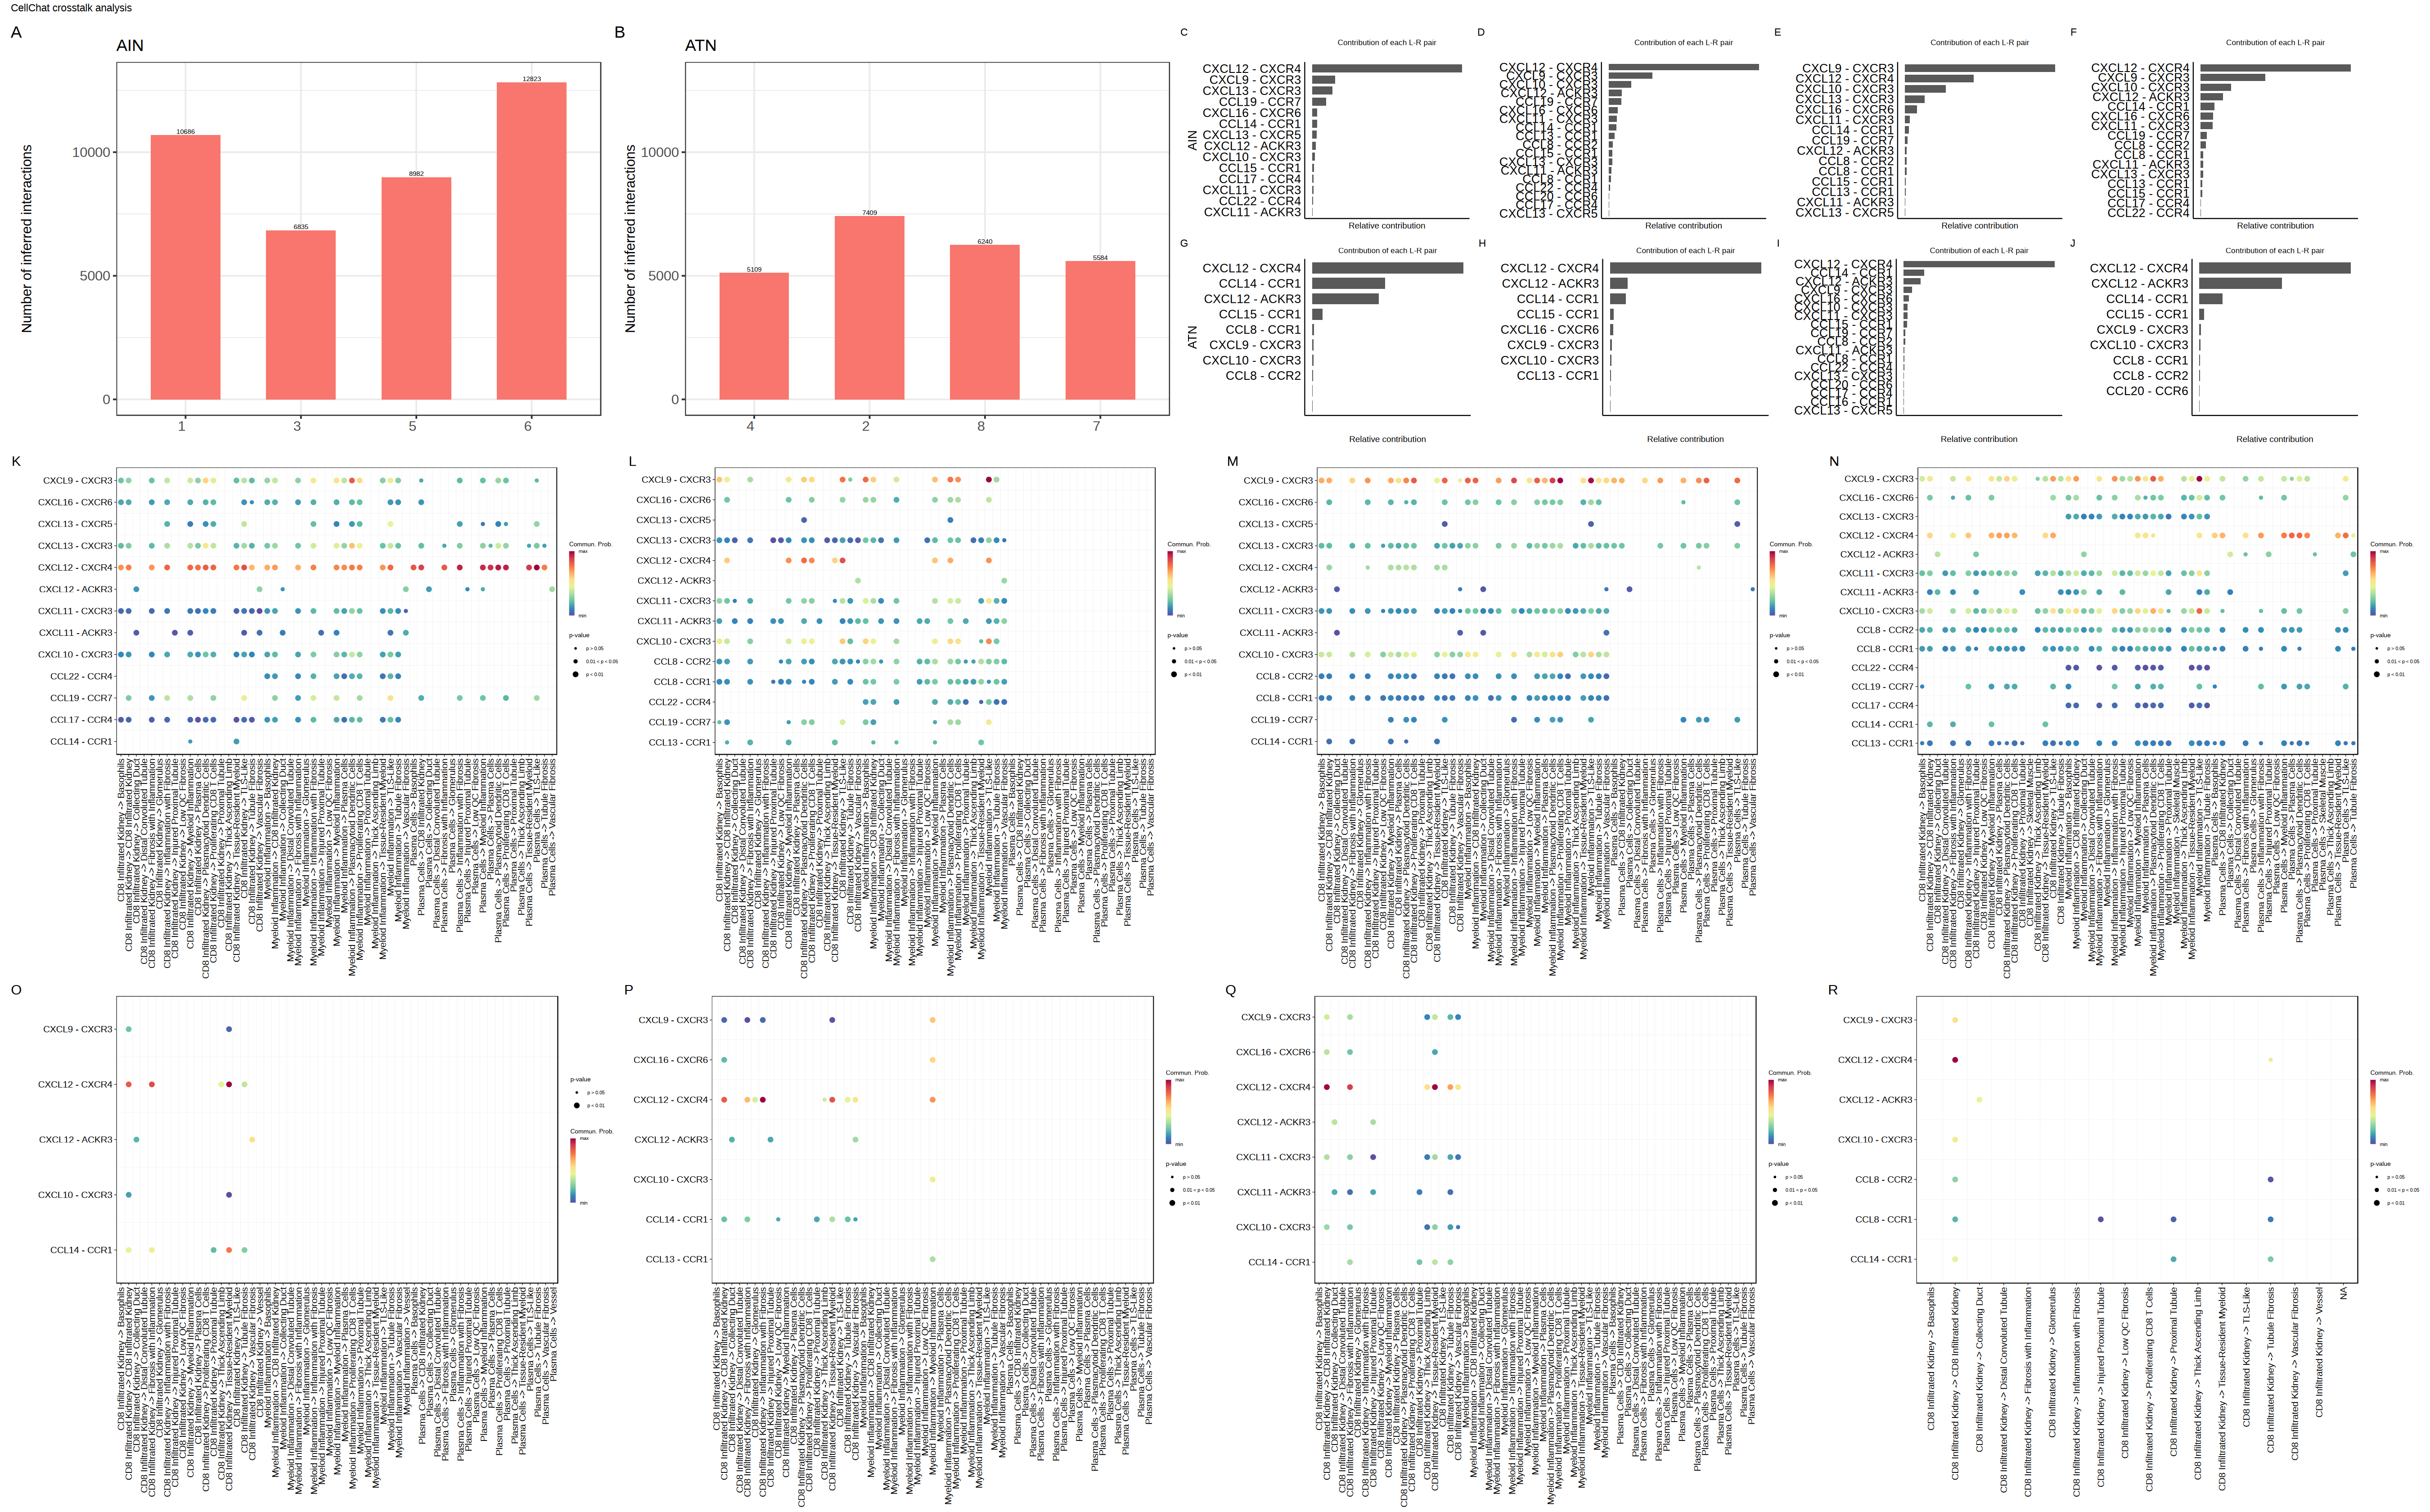

In [316]:
fig.size(28, 45)
(figs6a | figs6b) / (figs6c) + plot_layout(heights=c(3.9, 9)) + plot_annotation(title='CellChat crosstalk analysis', tag_levels = 'A')

In [317]:
ggsave("SuppFig6_CXCL_comparison.pdf", width=45, height=28)